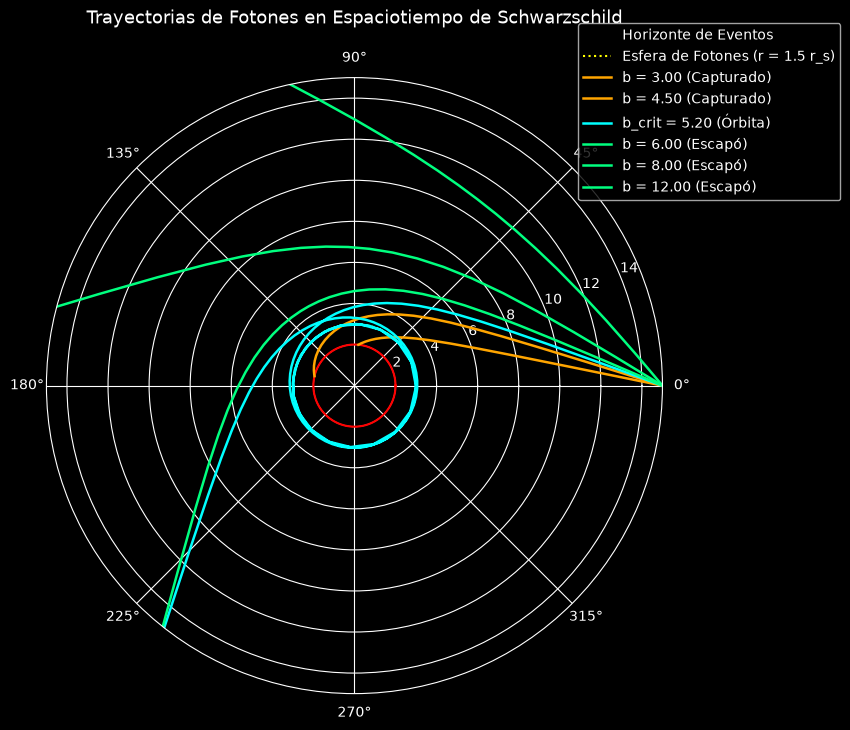

In [2]:

import numpy as np
import matplotlib.pyplot as plt
from physics.schwarzschild import SMetric
from physics.integrator import GeodesicIntegrator

# Configuración visual
plt.style.use('dark_background')
metric = SMetric()
integrator = GeodesicIntegrator(metric)

# Parámetros de impacto a probar
b_test_values = [3.0, 4.5, metric.b_crit, 6.0, 8.0, 12.0]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})

# Graficar el horizonte de eventos (negro)
phi_circle = np.linspace(0, 2*np.pi, 200)
ax.fill(phi_circle, np.full_like(phi_circle, metric.r_horizon), color='black', alpha=0.9, label="Horizonte de Eventos")
ax.plot(phi_circle, np.full_like(phi_circle, metric.r_horizon), color='red', linewidth=1.5)

# Graficar la esfera de fotones (amarilla punteada)
ax.plot(phi_circle, np.full_like(phi_circle, metric.r_photon), color='yellow', linestyle=':', label="Esfera de Fotones (r = 1.5 r_s)")

# Trazar cada geodésica
for b_val in b_test_values:
    res = integrator.integrate_ray(b=b_val, r0=15.0)
    
    if res['status'] == 'captured':
        label_text = f"b = {b_val:.2f} (Capturado)"
        color_line = 'orange'
    elif np.isclose(b_val, metric.b_crit):
        label_text = f"b_crit = {b_val:.2f} (Órbita)"
        color_line = 'cyan'
    else:
        label_text = f"b = {b_val:.2f} (Escapó)"
        color_line = 'springgreen'
        
    ax.plot(res['phi'], res['r'], label=label_text, color=color_line, linewidth=1.8)

ax.set_rlim(0, 15)
ax.set_title("Trayectorias de Fotones en Espaciotiempo de Schwarzschild", fontsize=13, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.show()

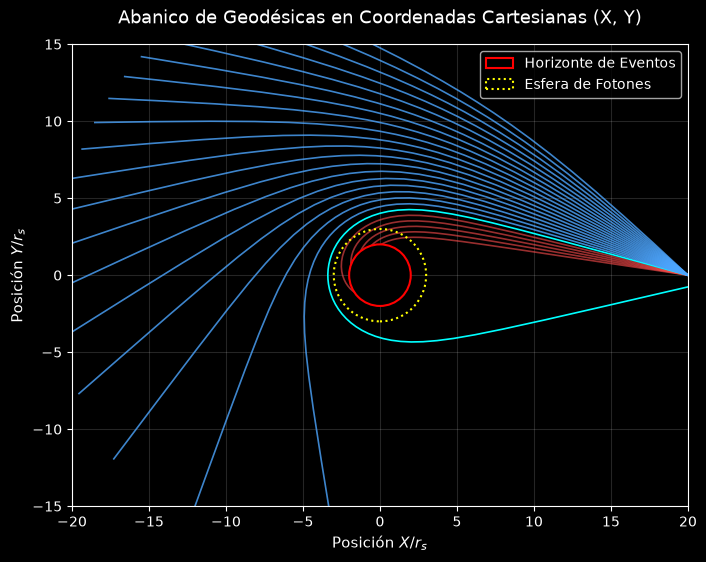

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from physics.schwarzschild import SMetric
from physics.integrator import GeodesicIntegrator

# Estilo oscuro
plt.style.use('dark_background')
metric = SMetric()
integrator = GeodesicIntegrator(metric)

fig, ax = plt.subplots(figsize=(10, 6))

# 1. Dibujar el Agujero Negro y Horizonte de Eventos
circle_horizon = plt.Circle((0, 0), metric.r_horizon, color='black', ec='red', lw=1.5, zorder=5, label="Horizonte de Eventos")
circle_photon = plt.Circle((0, 0), metric.r_photon, color='none', ec='yellow', ls=':', lw=1.5, zorder=4, label="Esfera de Fotones")
ax.add_patch(circle_horizon)
ax.add_patch(circle_photon)

# 2. Generar abanico de rayos con distintos b
b_values = np.linspace(1.5 * metric.r_s, 7.0 * metric.r_s, 25)

for b_val in b_values:
    res = integrator.integrate_ray(b=b_val, r0=20.0)
    
    # Conversión a coordenadas cartesianas (X, Y)
    X = res['r'] * np.cos(res['phi'])
    Y = res['r'] * np.sin(res['phi'])
    
    # Color según el estado
    if res['status'] == 'captured':
        color_line = '#ff4d4d'  # Rojo para capturados
        alpha = 0.6
    elif np.isclose(b_val, metric.b_crit, atol=0.1):
        color_line = 'cyan'     # Cian para la órbita crítica
        alpha = 1.0
    else:
        color_line = '#4da6ff'  # Azul para escapados
        alpha = 0.8
        
    ax.plot(X, Y, color=color_line, alpha=alpha, linewidth=1.2)

# Configuración del eje y límites
ax.set_aspect('equal')
ax.set_xlim(-20, 20)
ax.set_ylim(-15, 15)
ax.set_title("Abanico de Geodésicas en Coordenadas Cartesianas (X, Y)", fontsize=13, pad=15)
ax.set_xlabel(r"Posición $X / r_s$", fontsize=11)
ax.set_ylabel(r"Posición $Y / r_s$", fontsize=11)
ax.grid(True, alpha=0.15)
ax.legend(loc="upper right")

plt.show()